# LoRA/QLoRA 이론과 구조

> 전체 파라미터의 **1%만 학습**해서 Full Fine-tuning에 근접한 성능을 내는 원리를 파헤친다

Phase 3에서 데이터를 준비했다. 이제 그 데이터로 모델을 **실제로 학습**시키는 단계다.  
LoRA가 없으면 7B 모델 파인튜닝에 GPU 메모리 60GB+가 필요하다.  
LoRA를 쓰면 **16GB면 충분**하다. 왜 가능한지, 수학적으로 이해한다.

In [1]:
# === 환경 설치 ===
!pip install peft accelerate transformers bitsandbytes matplotlib numpy

   ---------------------------------------- 0.0/557.0 kB ? eta -:--:--
   ---------------------------------------- 557.0/557.0 kB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/54.7 MB ? eta -:--:--
   -- ------------------------------------- 3.4/54.7 MB 18.3 MB/s eta 0:00:03
   ----- ---------------------------------- 7.9/54.7 MB 20.3 MB/s eta 0:00:03
   --------- ------------------------------ 13.1/54.7 MB 22.2 MB/s eta 0:00:02
   ------------ --------------------------- 17.6/54.7 MB 22.2 MB/s eta 0:00:02
   ---------------- ----------------------- 22.8/54.7 MB 22.9 MB/s eta 0:00:02
   --------------------- ------------------ 29.1/54.7 MB 24.0 MB/s eta 0:00:02
   ------------------------ --------------- 34.1/54.7 MB 24.1 MB/s eta 0:00:01
   ----------------------------- ---------- 40.1/54.7 MB 24.8 MB/s eta 0:00:01
   -------------------------------- ------- 44.0/54.7 MB 24.4 MB/s eta 0:00:01
   ----------------------------------- ---- 48.8/54.7 MB 24.1 MB/s eta 0:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 1. Full Fine-tuning의 문제

사전학습된 모델의 **모든 가중치**를 업데이트하는 방식.  
성능은 좋지만, 현실적으로 불가능한 경우가 대부분이다.

In [3]:
# === Full Fine-tuning의 메모리 비용 ===
# 모델 파라미터 수에 따른 학습 시 GPU 메모리 추정
#
# 학습 시 필요한 메모리:
#   모델 가중치 (fp16)     : 파라미터 수 × 2 bytes
#   그래디언트 (fp16)       : 파라미터 수 × 2 bytes
#   옵티마이저 상태 (fp32)  : 파라미터 수 × 8 bytes (AdamW: m + v + master weight)
#   => 총 약 파라미터 수 × 12 bytes

model_sizes = {
    'Llama 3.1 8B': 8e9,
    'Mistral 7B': 7e9,
    'Qwen 2.5 7B': 7e9,
    'Llama 3.1 70B': 70e9,
}

print("Full Fine-tuning 시 GPU 메모리 요구량:")
print("=" * 55)
print(f"{'모델':<20} {'파라미터':>10} {'메모리 (GB)':>12} {'GPU 필요':>12}")
print("-" * 55)

for name, params in model_sizes.items():
    # fp16 학습 기준: 파라미터 × 12 bytes
    memory_gb = (params * 12) / (1024**3)
    
    if memory_gb <= 24:
        gpu = "RTX 4090 ×1"
    elif memory_gb <= 48:
        gpu = "A6000 ×1"
    elif memory_gb <= 80:
        gpu = "A100 ×1"
    else:
        num_gpus = int(np.ceil(memory_gb / 80))
        gpu = f"A100 ×{num_gpus}"
    
    print(f"{name:<20} {params/1e9:>8.0f}B {memory_gb:>10.1f}GB {gpu:>12}")

print("\n-> 8B 모델도 Full Fine-tuning은 A100급 GPU가 필요")
print("   70B는 개인이 접근 불가능한 영역")
print("\n   이 문제를 해결하는 것이 LoRA다.")

Full Fine-tuning 시 GPU 메모리 요구량:
모델                         파라미터     메모리 (GB)       GPU 필요
-------------------------------------------------------
Llama 3.1 8B                8B       89.4GB      A100 ×2
Mistral 7B                  7B       78.2GB      A100 ×1
Qwen 2.5 7B                 7B       78.2GB      A100 ×1
Llama 3.1 70B              70B      782.3GB     A100 ×10

-> 8B 모델도 Full Fine-tuning은 A100급 GPU가 필요
   70B는 개인이 접근 불가능한 영역

   이 문제를 해결하는 것이 LoRA다.


---
## 2. LoRA 핵심 원리: 저랭크 분해

**핵심 아이디어:** 파인튜닝 시 가중치 변화량 $\Delta W$는 **저차원(low-rank)**으로 충분히 표현된다.

$$W' = W + \Delta W = W + BA$$

- $W$: 원본 가중치 (동결, 학습 안 함)
- $B \in \mathbb{R}^{d \times r}$, $A \in \mathbb{R}^{r \times k}$: 학습할 저랭크 행렬
- $r \ll \min(d, k)$: 랭크 (보통 8~64)

In [4]:
# === LoRA 핵심 원리: 저랭크 분해 시각적 이해 ===
# 4096×4096 가중치를 직접 학습 vs LoRA로 분해

d = 4096  # 입력 차원 (Llama 8B의 hidden_size)
k = 4096  # 출력 차원

print("LoRA 저랭크 분해 원리:")
print("=" * 60)
print(f"\n원본 가중치 W: {d} × {k} = {d*k:,} 파라미터")
print(f"  -> 이걸 직접 학습하면 {d*k:,}개 전부 업데이트")

print(f"\nLoRA 분해 (W' = W + BA):")
for r in [4, 8, 16, 32, 64]:
    lora_params = d * r + r * k  # B: d×r, A: r×k
    ratio = lora_params / (d * k) * 100
    print(f"  r={r:>2}: B({d}×{r}) + A({r}×{k}) = {lora_params:>8,}개 ({ratio:.2f}%)")

print(f"\n-> r=16이면 원본의 0.78%만 학습")
print(f"   나머지 99.22%는 동결 (메모리에 그래디언트/옵티마이저 불필요)")

LoRA 저랭크 분해 원리:

원본 가중치 W: 4096 × 4096 = 16,777,216 파라미터
  -> 이걸 직접 학습하면 16,777,216개 전부 업데이트

LoRA 분해 (W' = W + BA):
  r= 4: B(4096×4) + A(4×4096) =   32,768개 (0.20%)
  r= 8: B(4096×8) + A(8×4096) =   65,536개 (0.39%)
  r=16: B(4096×16) + A(16×4096) =  131,072개 (0.78%)
  r=32: B(4096×32) + A(32×4096) =  262,144개 (1.56%)
  r=64: B(4096×64) + A(64×4096) =  524,288개 (3.12%)

-> r=16이면 원본의 0.78%만 학습
   나머지 99.22%는 동결 (메모리에 그래디언트/옵티마이저 불필요)


In [5]:
# === LoRA 연산을 numpy로 직접 구현 ===
# 수학을 코드로 확인

np.random.seed(42)

# 원본 가중치 (사전학습 결과, 동결)
d, k = 8, 6  # 작은 크기로 시연
W = np.random.randn(d, k)

# LoRA 행렬 (학습 대상)
r = 2  # rank
B = np.zeros((d, r))  # B는 0으로 초기화 (학습 시작 시 ΔW = 0)
A = np.random.randn(r, k)  # A는 랜덤 초기화

print("LoRA 초기 상태:")
print(f"  W shape: {W.shape} (동결)")
print(f"  B shape: {B.shape} (0으로 초기화)")
print(f"  A shape: {A.shape} (랜덤 초기화)")
print(f"  ΔW = B @ A:")
print(f"  {(B @ A).round(3)}")
print(f"\n  -> B가 0이므로 ΔW도 0 -> 학습 시작 시 W' = W (원본과 동일)")
print(f"     이것이 LoRA의 핵심: 학습 시작점이 사전학습 모델과 동일하게 보장됨")

# 학습 후 (B가 업데이트된 상태 시뮬레이션)
B_trained = np.random.randn(d, r) * 0.1  # 학습 후 작은 값
delta_W = B_trained @ A
W_new = W + delta_W

print(f"\n학습 후:")
print(f"  ΔW = B @ A (학습된 변화량):")
print(f"  ΔW의 평균 절대값: {np.abs(delta_W).mean():.4f}")
print(f"  W의 평균 절대값:  {np.abs(W).mean():.4f}")
print(f"  변화 비율: {np.abs(delta_W).mean() / np.abs(W).mean() * 100:.1f}%")
print(f"\n  -> 원본 가중치 대비 아주 작은 변화만으로 파인튜닝 달성")

LoRA 초기 상태:
  W shape: (8, 6) (동결)
  B shape: (8, 2) (0으로 초기화)
  A shape: (2, 6) (랜덤 초기화)
  ΔW = B @ A:
  [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

  -> B가 0이므로 ΔW도 0 -> 학습 시작 시 W' = W (원본과 동일)
     이것이 LoRA의 핵심: 학습 시작점이 사전학습 모델과 동일하게 보장됨

학습 후:
  ΔW = B @ A (학습된 변화량):
  ΔW의 평균 절대값: 0.0941
  W의 평균 절대값:  0.7545
  변화 비율: 12.5%

  -> 원본 가중치 대비 아주 작은 변화만으로 파인튜닝 달성


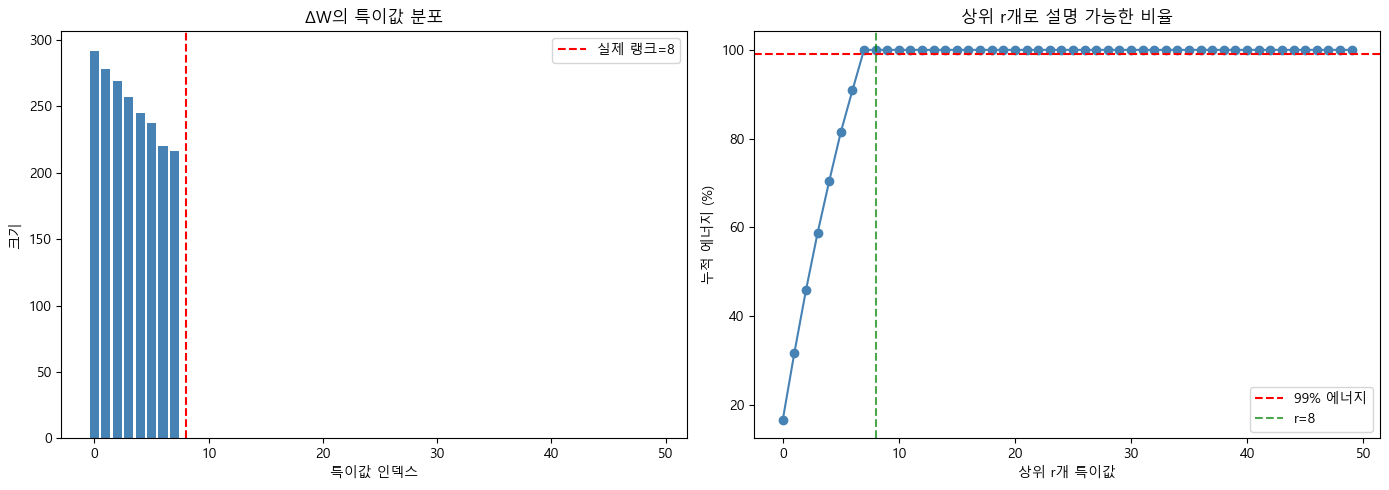

  r= 4: 전체 변화의 58.7% 설명
  r= 8: 전체 변화의 100.0% 설명
  r=16: 전체 변화의 100.0% 설명
  r=32: 전체 변화의 100.0% 설명

-> 상위 8개 특이값이 거의 모든 변화를 설명
   나머지는 노이즈 -> LoRA가 작동하는 수학적 근거


In [6]:
# === LoRA가 가능한 이유: 가중치 변화의 본질적 랭크 ===
# 실제 파인튜닝에서 ΔW의 특이값(singular value)을 보면
# 상위 몇 개만 유의미하고 나머지는 거의 0이다

# 시뮬레이션: Full Fine-tuning의 ΔW가 실제로 저랭크인지 확인
d, k = 256, 256

# 가상의 ΔW: 실제 유의미한 변화는 소수 방향에 집중
# 랭크 8인 행렬 + 약간의 노이즈 = 실제 파인튜닝 ΔW와 유사
true_rank = 8
U = np.random.randn(d, true_rank)
V = np.random.randn(true_rank, k)
delta_W_simulated = U @ V + np.random.randn(d, k) * 0.01

# SVD로 분해하여 특이값 확인
singular_values = np.linalg.svd(delta_W_simulated, compute_uv=False)

# 상위 r개 특이값이 전체 에너지의 몇 %인지
total_energy = np.sum(singular_values**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 특이값 분포
axes[0].bar(range(min(50, len(singular_values))), singular_values[:50], color='steelblue')
axes[0].axvline(x=true_rank, color='r', linestyle='--', label=f'실제 랭크={true_rank}')
axes[0].set_xlabel('특이값 인덱스')
axes[0].set_ylabel('크기')
axes[0].set_title('ΔW의 특이값 분포')
axes[0].legend()

# 2) 누적 에너지 비율
cumulative_energy = np.cumsum(singular_values**2) / total_energy * 100
axes[1].plot(range(min(50, len(cumulative_energy))), cumulative_energy[:50], 'o-', color='steelblue')
axes[1].axhline(y=99, color='r', linestyle='--', label='99% 에너지')
axes[1].axvline(x=true_rank, color='g', linestyle='--', alpha=0.7, label=f'r={true_rank}')
axes[1].set_xlabel('상위 r개 특이값')
axes[1].set_ylabel('누적 에너지 (%)')
axes[1].set_title('상위 r개로 설명 가능한 비율')
axes[1].legend()

plt.tight_layout()
plt.show()

for r_test in [4, 8, 16, 32]:
    energy = np.sum(singular_values[:r_test]**2) / total_energy * 100
    print(f"  r={r_test:>2}: 전체 변화의 {energy:.1f}% 설명")

print(f"\n-> 상위 {true_rank}개 특이값이 거의 모든 변화를 설명")
print(f"   나머지는 노이즈 -> LoRA가 작동하는 수학적 근거")

---
## 3. LoRA 핵심 하이퍼파라미터

| 파라미터 | 역할 | 권장값 |
|----------|------|--------|
| **r** (rank) | 저차원 행렬의 랭크 | 8, 16, 32, 64 |
| **alpha** | 스케일링 팩터 | r의 2배 |
| **target_modules** | LoRA를 적용할 레이어 | q_proj, v_proj (최소) |
| **dropout** | LoRA 레이어의 드롭아웃 | 0.05~0.1 |

In [7]:
# === r (rank)의 영향 분석 ===
# r이 커질수록 표현력 ↑, 파라미터 수 ↑, 과적합 위험 ↑

# Llama 8B 기준 (hidden_size=4096)
hidden_size = 4096
num_attention_layers = 32  # Llama 8B의 레이어 수
# 각 레이어: q_proj, k_proj, v_proj, o_proj (4개 attention projection)
num_target_per_layer = 4
total_targets = num_attention_layers * num_target_per_layer

print("r (rank)에 따른 학습 파라미터 수 (Llama 8B, attention만):")
print("=" * 65)
print(f"{'r':>4} {'LoRA 파라미터':>15} {'전체 대비 %':>12} {'추가 메모리':>12}")
print("-" * 65)

total_model_params = 8e9
ranks = [4, 8, 16, 32, 64, 128]
lora_params_list = []

for r in ranks:
    # 각 target: (hidden_size × r + r × hidden_size) = 2 × hidden_size × r
    params_per_target = 2 * hidden_size * r
    total_lora_params = params_per_target * total_targets
    ratio = total_lora_params / total_model_params * 100
    memory_mb = total_lora_params * 2 / (1024**2)  # fp16
    lora_params_list.append(total_lora_params)
    
    print(f"{r:>4} {total_lora_params:>13,} {ratio:>10.3f}% {memory_mb:>9.1f}MB")

print(f"\n-> r=16: 전체의 0.05%만 학습하면서 충분한 표현력")
print(f"   r=64: 0.21% — 더 복잡한 태스크에 적합")
print(f"   r=128 이상: 과적합 위험, 대부분 불필요")

r (rank)에 따른 학습 파라미터 수 (Llama 8B, attention만):
   r       LoRA 파라미터      전체 대비 %       추가 메모리
-----------------------------------------------------------------
   4     4,194,304      0.052%       8.0MB
   8     8,388,608      0.105%      16.0MB
  16    16,777,216      0.210%      32.0MB
  32    33,554,432      0.419%      64.0MB
  64    67,108,864      0.839%     128.0MB
 128   134,217,728      1.678%     256.0MB

-> r=16: 전체의 0.05%만 학습하면서 충분한 표현력
   r=64: 0.21% — 더 복잡한 태스크에 적합
   r=128 이상: 과적합 위험, 대부분 불필요


In [8]:
# === alpha와 스케일링 메커니즘 ===
# 실제 LoRA 출력: ΔW = (alpha / r) × B @ A
# alpha/r 비율이 LoRA의 '학습률 배수'처럼 작동

print("alpha/r 스케일링 메커니즘:")
print("=" * 60)
print("\n  실제 수식: output = W·x + (alpha/r) × B·A·x")
print("  alpha/r가 LoRA 업데이트의 스케일을 결정\n")

print(f"{'r':>4} {'alpha':>6} {'alpha/r':>8} {'효과':>25}")
print("-" * 50)

configs = [
    (8, 8, "보수적: 변화량 작음"),
    (8, 16, "표준: r의 2배 (권장)"),
    (8, 32, "공격적: 변화량 큼"),
    (16, 16, "보수적"),
    (16, 32, "표준 (권장)"),
    (32, 64, "표준 (권장)"),
]

for r, alpha, effect in configs:
    scale = alpha / r
    print(f"{r:>4} {alpha:>6} {scale:>8.1f} {effect:>25}")

print("\n핵심 규칙:")
print("  1. alpha = r × 2가 가장 안전한 시작점")
print("  2. alpha/r이 클수록 LoRA의 영향력이 커짐")
print("  3. r을 바꿀 때 alpha도 비례해서 바꾸면 스케일 일정")
print("  4. alpha 고정 + r만 변경 = r이 커질수록 개별 랭크 기여 감소")

alpha/r 스케일링 메커니즘:

  실제 수식: output = W·x + (alpha/r) × B·A·x
  alpha/r가 LoRA 업데이트의 스케일을 결정

   r  alpha  alpha/r                        효과
--------------------------------------------------
   8      8      1.0               보수적: 변화량 작음
   8     16      2.0            표준: r의 2배 (권장)
   8     32      4.0                공격적: 변화량 큼
  16     16      1.0                       보수적
  16     32      2.0                   표준 (권장)
  32     64      2.0                   표준 (권장)

핵심 규칙:
  1. alpha = r × 2가 가장 안전한 시작점
  2. alpha/r이 클수록 LoRA의 영향력이 커짐
  3. r을 바꿀 때 alpha도 비례해서 바꾸면 스케일 일정
  4. alpha 고정 + r만 변경 = r이 커질수록 개별 랭크 기여 감소


In [9]:
# === target_modules: 어디에 LoRA를 적용하는가 ===
# Transformer 내부 구조와 LoRA 적용 위치

print("Transformer 레이어 내부 구조와 LoRA 적용 위치:")
print("=" * 60)
print("""
┌─────────────────────────────────────────────┐
│          Transformer Layer (×32)             │
│                                             │
│  ┌── Self-Attention ──────────────────────┐ │
│  │  q_proj (4096→4096)  ← LoRA 적용 ✓    │ │
│  │  k_proj (4096→1024)  ← LoRA 적용 ✓    │ │
│  │  v_proj (4096→1024)  ← LoRA 적용 ✓    │ │
│  │  o_proj (4096→4096)  ← LoRA 적용 ✓    │ │
│  └────────────────────────────────────────┘ │
│                                             │
│  ┌── Feed-Forward (MLP) ──────────────────┐ │
│  │  gate_proj (4096→14336) ← LoRA 선택적  │ │
│  │  up_proj   (4096→14336) ← LoRA 선택적  │ │
│  │  down_proj (14336→4096) ← LoRA 선택적  │ │
│  └────────────────────────────────────────┘ │
└─────────────────────────────────────────────┘
""")

# 적용 범위별 파라미터 비교
configs = {
    'q,v만 (최소)': ['q_proj', 'v_proj'],
    'q,k,v,o (attention 전체)': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'attention + MLP (전체)': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
}

# Llama 8B 기준 각 projection의 파라미터 수
proj_sizes = {
    'q_proj': 4096 * 4096,
    'k_proj': 4096 * 1024,
    'v_proj': 4096 * 1024,
    'o_proj': 4096 * 4096,
    'gate_proj': 4096 * 14336,
    'up_proj': 4096 * 14336,
    'down_proj': 14336 * 4096,
}

r = 16
print(f"target_modules 설정에 따른 학습량 (r={r}, 32 레이어):")
print("-" * 60)

for config_name, modules in configs.items():
    total = 0
    for mod in modules:
        # LoRA 파라미터: (input_dim + output_dim) × r
        orig = proj_sizes[mod]
        in_dim = 4096 if 'down' not in mod else 14336
        out_dim = orig // in_dim
        lora_per_module = (in_dim + out_dim) * r
        total += lora_per_module * 32  # 32 레이어
    
    ratio = total / 8e9 * 100
    print(f"  {config_name}")
    print(f"    LoRA 파라미터: {total:,} ({ratio:.3f}%)")

print("\n실전 가이드:")
print("  - 간단한 태스크 (분류, 형식 변환): q,v만으로 충분")
print("  - 복잡한 태스크 (코드 생성, 추론): attention + MLP 전체")
print("  - 메모리 부족: target 줄이기 > r 줄이기 (효과적)")

Transformer 레이어 내부 구조와 LoRA 적용 위치:

┌─────────────────────────────────────────────┐
│          Transformer Layer (×32)             │
│                                             │
│  ┌── Self-Attention ──────────────────────┐ │
│  │  q_proj (4096→4096)  ← LoRA 적용 ✓    │ │
│  │  k_proj (4096→1024)  ← LoRA 적용 ✓    │ │
│  │  v_proj (4096→1024)  ← LoRA 적용 ✓    │ │
│  │  o_proj (4096→4096)  ← LoRA 적용 ✓    │ │
│  └────────────────────────────────────────┘ │
│                                             │
│  ┌── Feed-Forward (MLP) ──────────────────┐ │
│  │  gate_proj (4096→14336) ← LoRA 선택적  │ │
│  │  up_proj   (4096→14336) ← LoRA 선택적  │ │
│  │  down_proj (14336→4096) ← LoRA 선택적  │ │
│  └────────────────────────────────────────┘ │
└─────────────────────────────────────────────┘

target_modules 설정에 따른 학습량 (r=16, 32 레이어):
------------------------------------------------------------
  q,v만 (최소)
    LoRA 파라미터: 6,815,744 (0.085%)
  q,k,v,o (attention 전체)
    LoRA 파라미터: 13,631,488 (0.170%)
  atte

---
## 4. QLoRA: 4-bit 양자화 + LoRA

LoRA만으로도 학습 파라미터는 줄었지만, **원본 모델 자체**를 메모리에 올려야 한다.  
QLoRA는 원본 모델을 **4-bit로 압축**해서 메모리를 추가로 75% 절감한다.

In [10]:
# === QLoRA의 메모리 절감 원리 ===

print("데이터 타입별 모델 메모리 (8B 모델):")
print("=" * 55)

params = 8e9
dtypes = {
    'float32 (Full)': 4,
    'float16 / bfloat16': 2,
    'int8 (8-bit 양자화)': 1,
    'NF4 (4-bit QLoRA)': 0.5,
}

print(f"{'데이터 타입':<25} {'바이트/파라미터':>12} {'메모리 (GB)':>12}")
print("-" * 55)
for name, bytes_per in dtypes.items():
    mem_gb = params * bytes_per / (1024**3)
    print(f"{name:<25} {bytes_per:>10} B {mem_gb:>10.1f} GB")

print("\nQLoRA = NF4 양자화(모델) + LoRA(학습):")
print(f"  모델 로드:     {params * 0.5 / (1024**3):.1f} GB (NF4)")
print(f"  LoRA 파라미터: ~0.1 GB (fp16, 학습용)")
print(f"  그래디언트:    ~0.1 GB")
print(f"  옵티마이저:    ~0.2 GB")
print(f"  ─────────────────────")
print(f"  합계:          ~{params * 0.5 / (1024**3) + 0.4:.1f} GB")
print(f"\n-> RTX 4090 (24GB)에서 8B 모델 파인튜닝 가능!")

데이터 타입별 모델 메모리 (8B 모델):
데이터 타입                        바이트/파라미터     메모리 (GB)
-------------------------------------------------------
float32 (Full)                     4 B       29.8 GB
float16 / bfloat16                 2 B       14.9 GB
int8 (8-bit 양자화)                   1 B        7.5 GB
NF4 (4-bit QLoRA)                0.5 B        3.7 GB

QLoRA = NF4 양자화(모델) + LoRA(학습):
  모델 로드:     3.7 GB (NF4)
  LoRA 파라미터: ~0.1 GB (fp16, 학습용)
  그래디언트:    ~0.1 GB
  옵티마이저:    ~0.2 GB
  ─────────────────────
  합계:          ~4.1 GB

-> RTX 4090 (24GB)에서 8B 모델 파인튜닝 가능!


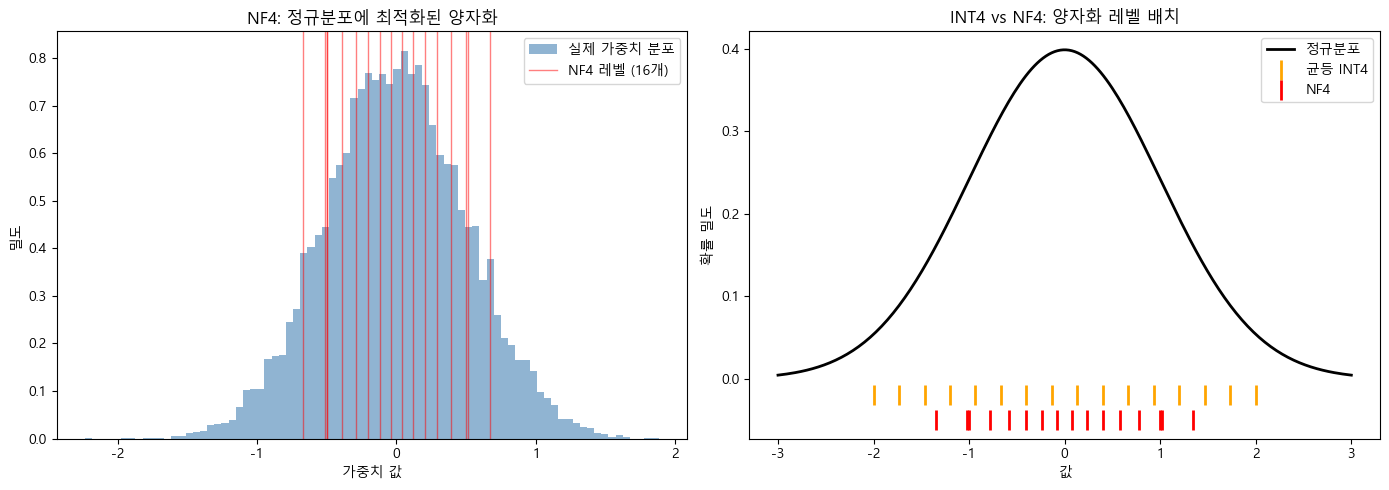

NF4의 핵심:
  - 균등 INT4: 값이 몰려있는 중심부에서 정밀도 낭비
  - NF4: 값이 많은 곳에 레벨을 촘촘히 배치 -> 양자화 오차 최소화
  - 신경망 가중치는 거의 항상 정규분포 -> NF4가 이론적 최적


In [11]:
# === NormalFloat4 (NF4) 양자화 ===
# QLoRA의 핵심 혁신: 정규분포를 기반으로 4-bit 값을 배정
# 신경망 가중치가 정규분포를 따르는 성질을 이용

from scipy import stats

# NF4: 정규분포의 동일 확률 구간을 16개로 나누어 양자화
# 각 구간에 동일한 수의 값이 떨어지도록 설계

n_levels = 16  # 4-bit = 2^4 = 16 레벨
quantiles = np.linspace(0, 1, n_levels + 1)
nf4_values = stats.norm.ppf(quantiles)  # 정규분포 분위수
nf4_centers = (nf4_values[:-1] + nf4_values[1:]) / 2  # 각 구간 중심
nf4_centers[0] = -1.0  # 극단값 클리핑
nf4_centers[-1] = 1.0

# 일반 int4 대비 NF4의 장점 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 정규분포 가중치 시뮬레이션
weights = np.random.randn(10000) * 0.5

# 1) 가중치 분포와 NF4 양자화 레벨
axes[0].hist(weights, bins=80, density=True, alpha=0.6, color='steelblue', label='실제 가중치 분포')
for v in nf4_centers:
    axes[0].axvline(x=v * 0.5, color='red', alpha=0.5, linewidth=1)
axes[0].axvline(x=nf4_centers[0] * 0.5, color='red', alpha=0.5, linewidth=1, label='NF4 레벨 (16개)')
axes[0].set_xlabel('가중치 값')
axes[0].set_ylabel('밀도')
axes[0].set_title('NF4: 정규분포에 최적화된 양자화')
axes[0].legend()

# 2) 균등 int4 vs NF4 비교
uniform_levels = np.linspace(-2, 2, 16)  # 균등 배치
x = np.linspace(-3, 3, 200)
pdf = stats.norm.pdf(x)

axes[1].plot(x, pdf, 'k-', linewidth=2, label='정규분포')
axes[1].scatter(uniform_levels, np.zeros_like(uniform_levels) - 0.02, 
               marker='|', s=200, color='orange', linewidths=2, label='균등 INT4')
axes[1].scatter(nf4_centers, np.zeros_like(nf4_centers) - 0.05,
               marker='|', s=200, color='red', linewidths=2, label='NF4')
axes[1].set_xlabel('값')
axes[1].set_ylabel('확률 밀도')
axes[1].set_title('INT4 vs NF4: 양자화 레벨 배치')
axes[1].legend()

plt.tight_layout()
plt.show()

print("NF4의 핵심:")
print("  - 균등 INT4: 값이 몰려있는 중심부에서 정밀도 낭비")
print("  - NF4: 값이 많은 곳에 레벨을 촘촘히 배치 -> 양자화 오차 최소화")
print("  - 신경망 가중치는 거의 항상 정규분포 -> NF4가 이론적 최적")

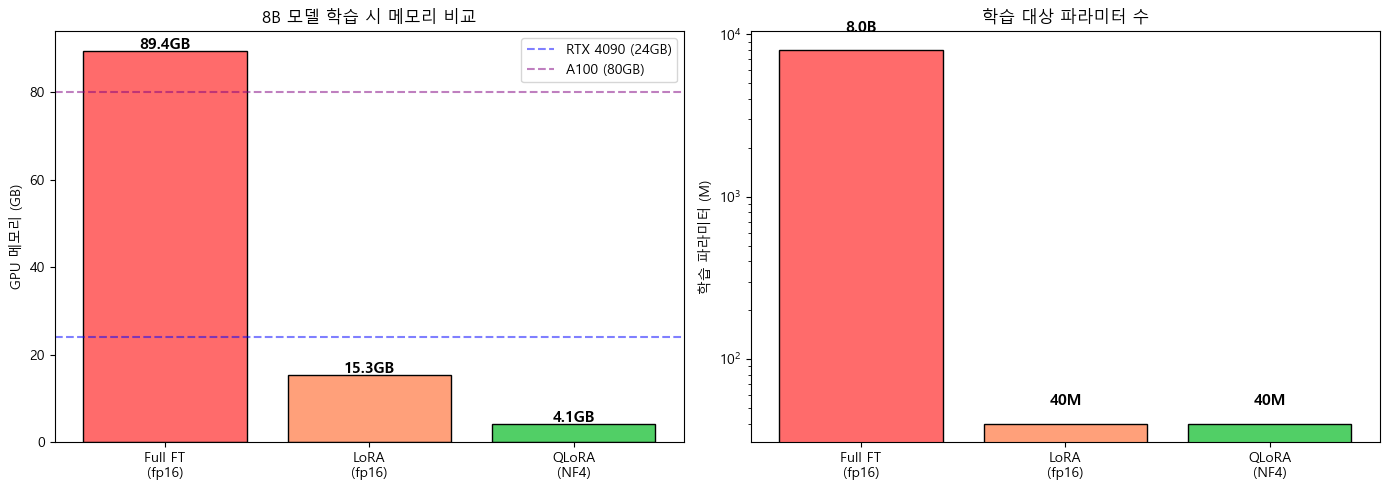

정리:
  Full FT: 최고 성능, 비현실적 메모리
  LoRA:    1% 학습, 성능 근접, 메모리 절반
  QLoRA:   1% 학습, 성능 근접, 메모리 1/4

-> 개인/소규모 팀은 QLoRA가 사실상 유일한 선택


In [12]:
# === LoRA vs QLoRA vs Full Fine-tuning 비교 ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 메모리 비교
methods = ['Full FT\n(fp16)', 'LoRA\n(fp16)', 'QLoRA\n(NF4)']
memory_gb = [
    8e9 * 12 / (1024**3),   # Full: 파라미터 × 12 bytes
    8e9 * 2 / (1024**3) + 0.4,  # LoRA: 모델(fp16) + LoRA 학습
    8e9 * 0.5 / (1024**3) + 0.4,  # QLoRA: 모델(NF4) + LoRA 학습
]
colors = ['#ff6b6b', '#ffa07a', '#51cf66']
bars = axes[0].bar(methods, memory_gb, color=colors, edgecolor='black')
axes[0].set_ylabel('GPU 메모리 (GB)')
axes[0].set_title('8B 모델 학습 시 메모리 비교')
for bar, mem in zip(bars, memory_gb):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
               f'{mem:.1f}GB', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(y=24, color='blue', linestyle='--', alpha=0.5, label='RTX 4090 (24GB)')
axes[0].axhline(y=80, color='purple', linestyle='--', alpha=0.5, label='A100 (80GB)')
axes[0].legend()

# 2) 학습 파라미터 비교
trainable = [
    8e9,       # Full FT
    8e9 * 0.005,  # LoRA (~0.5%)
    8e9 * 0.005,  # QLoRA (LoRA와 동일)
]
trainable_labels = ['8.0B', f'{trainable[1]/1e6:.0f}M', f'{trainable[2]/1e6:.0f}M']

bars2 = axes[1].bar(methods, [t/1e6 for t in trainable], color=colors, edgecolor='black')
axes[1].set_ylabel('학습 파라미터 (M)')
axes[1].set_title('학습 대상 파라미터 수')
axes[1].set_yscale('log')
for bar, label in zip(bars2, trainable_labels):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.3,
               label, ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("정리:")
print("  Full FT: 최고 성능, 비현실적 메모리")
print("  LoRA:    1% 학습, 성능 근접, 메모리 절반")
print("  QLoRA:   1% 학습, 성능 근접, 메모리 1/4")
print("\n-> 개인/소규모 팀은 QLoRA가 사실상 유일한 선택")

---
## 5. PEFT 라이브러리로 LoRA 적용하기

이론을 코드로 옮긴다. HuggingFace PEFT 라이브러리가 표준이다.

In [13]:
# === PEFT LoraConfig 설정 ===
from peft import LoraConfig, TaskType, get_peft_model

# LoRA 설정 객체 생성
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  # Causal Language Model (GPT 계열)
    r=16,                          # 랭크
    lora_alpha=32,                 # 스케일링 (alpha/r = 2)
    lora_dropout=0.05,             # 드롭아웃
    target_modules=[               # LoRA 적용 대상
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",                   # bias는 학습하지 않음
)

print("LoRA 설정:")
print("=" * 50)
print(f"  task_type:      {lora_config.task_type}")
print(f"  r (rank):       {lora_config.r}")
print(f"  alpha:          {lora_config.lora_alpha}")
print(f"  alpha/r:        {lora_config.lora_alpha / lora_config.r}")
print(f"  dropout:        {lora_config.lora_dropout}")
print(f"  target_modules: {lora_config.target_modules}")
print(f"  bias:           {lora_config.bias}")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LoRA 설정:
  task_type:      CAUSAL_LM
  r (rank):       16
  alpha:          32
  alpha/r:        2.0
  dropout:        0.05
  target_modules: {'o_proj', 'q_proj', 'up_proj', 'v_proj', 'down_proj', 'gate_proj', 'k_proj'}
  bias:           none


In [14]:
# === 실제 모델에 LoRA 적용 ===
# GPT-2 (124M)를 사용하여 LoRA 적용 전/후 비교
# GPU 없이도 CPU에서 실행 가능

from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "gpt2"  # 124M 파라미터 — 실습용

print(f"모델 로딩: {model_name}")
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 원본 파라미터 수
total_params = sum(p.numel() for p in model.parameters())
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n원본 모델:")
print(f"  전체 파라미터: {total_params:,}")
print(f"  학습 가능:     {trainable_before:,} (100%)")

모델 로딩: gpt2


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1113.46it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



원본 모델:
  전체 파라미터: 124,439,808
  학습 가능:     124,439,808 (100%)


In [15]:
# === GPT-2에 LoRA 적용 ===
# GPT-2의 attention projection 이름은 c_attn, c_proj

lora_config_gpt2 = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["c_attn", "c_proj"],  # GPT-2의 attention 레이어
)

# PEFT 모델 생성
peft_model = get_peft_model(model, lora_config_gpt2)

# LoRA 적용 후 파라미터 수
peft_model.print_trainable_parameters()

# 상세 분석
trainable_after = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in peft_model.parameters() if not p.requires_grad)

print(f"\nLoRA 적용 후:")
print(f"  동결 파라미터:    {frozen:,}")
print(f"  학습 파라미터:    {trainable_after:,}")
print(f"  학습 비율:        {trainable_after/frozen*100:.4f}%")
print(f"  메모리 절감 효과: 그래디언트 + 옵티마이저가 {trainable_after:,}개에만 필요")

Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte


trainable params: 811,008 || all params: 125,250,816 || trainable%: 0.6475

LoRA 적용 후:
  동결 파라미터:    124,439,808
  학습 파라미터:    811,008
  학습 비율:        0.6517%
  메모리 절감 효과: 그래디언트 + 옵티마이저가 811,008개에만 필요


c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\peft\tuners\lora\layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [16]:
# === LoRA 레이어 구조 확인 ===
# 모델 내부에서 LoRA가 어떻게 삽입되었는지 확인

print("LoRA 적용된 레이어 구조 (첫 번째 Transformer 블록):")
print("=" * 60)

# 첫 번째 블록의 attention 레이어만 출력
for name, module in peft_model.named_modules():
    if 'h.0.attn' in name and ('lora' in name or name.endswith('c_attn') or name.endswith('c_proj')):
        # 파라미터가 있는 모듈만 출력
        params = sum(p.numel() for p in module.parameters(recurse=False))
        if params > 0:
            print(f"  {name}: {params:,} params")

print("\n모델 전체에서 LoRA가 적용된 모듈:")
lora_modules = [name for name, _ in peft_model.named_modules() if 'lora_A' in name]
print(f"  총 {len(lora_modules)}개 LoRA-A 모듈")
print(f"  (각각에 대응하는 LoRA-B도 존재)")
for name in lora_modules[:6]:  # 처음 6개만
    print(f"    {name}")
if len(lora_modules) > 6:
    print(f"    ... (총 {len(lora_modules)}개)")

LoRA 적용된 레이어 구조 (첫 번째 Transformer 블록):
  base_model.model.transformer.h.0.attn.c_attn.lora_A.default: 6,144 params
  base_model.model.transformer.h.0.attn.c_attn.lora_B.default: 18,432 params
  base_model.model.transformer.h.0.attn.c_proj.lora_A.default: 6,144 params
  base_model.model.transformer.h.0.attn.c_proj.lora_B.default: 6,144 params

모델 전체에서 LoRA가 적용된 모듈:
  총 72개 LoRA-A 모듈
  (각각에 대응하는 LoRA-B도 존재)
    base_model.model.transformer.h.0.attn.c_attn.lora_A
    base_model.model.transformer.h.0.attn.c_attn.lora_A.default
    base_model.model.transformer.h.0.attn.c_proj.lora_A
    base_model.model.transformer.h.0.attn.c_proj.lora_A.default
    base_model.model.transformer.h.0.mlp.c_proj.lora_A
    base_model.model.transformer.h.0.mlp.c_proj.lora_A.default
    ... (총 72개)


In [17]:
# === LoRA 모델의 추론 확인 ===
# LoRA 적용 후에도 정상 추론이 되는지 확인
# (학습 전이므로 원본과 동일한 출력이 나와야 함 - B가 0이니까)

peft_model.eval()
test_text = "The future of AI is"
inputs = tokenizer(test_text, return_tensors="pt")

with torch.no_grad():
    outputs = peft_model.generate(
        **inputs,
        max_new_tokens=30,
        do_sample=False,  # greedy decoding
    )

generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"입력: {test_text}")
print(f"출력: {generated}")
print(f"\n-> LoRA 적용 직후(학습 전)에는 원본과 동일하게 동작")
print(f"   B가 0으로 초기화되어 ΔW = 0이기 때문")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


입력: The future of AI is
출력: The future of AI is uncertain. The future of AI is uncertain.

The future of AI is uncertain. The future of AI is uncertain.

The future of

-> LoRA 적용 직후(학습 전)에는 원본과 동일하게 동작
   B가 0으로 초기화되어 ΔW = 0이기 때문


---
## 6. QLoRA 설정 코드

실제 파인튜닝에서 사용할 QLoRA 설정 패턴.  
다음 노트북(02)에서 이 설정으로 실제 학습을 돌린다.

In [18]:
# === QLoRA 전체 설정 템플릿 ===
# 다음 노트북에서 실제로 사용할 설정을 미리 정의

from transformers import BitsAndBytesConfig

# 4-bit 양자화 설정
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                # 4-bit로 로드
    bnb_4bit_quant_type="nf4",        # NormalFloat4 (QLoRA 논문 방식)
    bnb_4bit_compute_dtype=torch.bfloat16,  # 연산은 bfloat16으로
    bnb_4bit_use_double_quant=True,   # 양자화 상수도 양자화 (추가 절감)
)

print("QLoRA BitsAndBytes 설정:")
print("=" * 55)
print(f"  load_in_4bit:          {bnb_config.load_in_4bit}")
print(f"  bnb_4bit_quant_type:   {bnb_config.bnb_4bit_quant_type}")
print(f"  bnb_4bit_compute_dtype:{bnb_config.bnb_4bit_compute_dtype}")
print(f"  double_quant:          {bnb_config.bnb_4bit_use_double_quant}")

print("\n각 설정의 의미:")
print("  load_in_4bit:     모델 가중치를 4-bit로 양자화하여 로드")
print("  nf4:              정규분포 최적 양자화 (int4 대비 정밀도 높음)")
print("  compute_dtype:    실제 연산 시 bfloat16으로 역양자화 (속도+정밀도)")
print("  double_quant:     양자화 스케일 팩터도 8-bit로 압축 (추가 0.4GB 절감)")

QLoRA BitsAndBytes 설정:
  load_in_4bit:          True
  bnb_4bit_quant_type:   nf4
  bnb_4bit_compute_dtype:torch.bfloat16
  double_quant:          True

각 설정의 의미:
  load_in_4bit:     모델 가중치를 4-bit로 양자화하여 로드
  nf4:              정규분포 최적 양자화 (int4 대비 정밀도 높음)
  compute_dtype:    실제 연산 시 bfloat16으로 역양자화 (속도+정밀도)
  double_quant:     양자화 스케일 팩터도 8-bit로 압축 (추가 0.4GB 절감)


In [19]:
# === 다음 노트북에서 사용할 전체 설정 미리보기 ===

print("Phase 4 전체 파인튜닝 설정 (다음 노트북):")
print("=" * 60)
print("""
1. 모델 로드 (QLoRA)
   model = AutoModelForCausalLM.from_pretrained(
       "Qwen/Qwen2.5-1.5B-Instruct",
       quantization_config=bnb_config,  # 4-bit 로드
       device_map="auto",
   )

2. LoRA 적용
   peft_model = get_peft_model(model, lora_config)

3. 학습 설정
   TrainingArguments(
       per_device_train_batch_size=4,
       gradient_accumulation_steps=4,  # 실효 배치=16
       num_train_epochs=3,
       learning_rate=2e-4,
       fp16=True,
       logging_steps=10,
       output_dir="./output",
   )

4. SFTTrainer 실행
   trainer = SFTTrainer(
       model=peft_model,
       train_dataset=train_data,    # Phase 3 파이프라인 출력
       args=training_args,
       max_seq_length=512,          # Phase 3 데이터 카드 기준
   )
   trainer.train()
""")
print("-> 02_SFT_첫_파인튜닝.ipynb에서 이 흐름을 실제로 실행한다")

Phase 4 전체 파인튜닝 설정 (다음 노트북):

1. 모델 로드 (QLoRA)
   model = AutoModelForCausalLM.from_pretrained(
       "Qwen/Qwen2.5-1.5B-Instruct",
       quantization_config=bnb_config,  # 4-bit 로드
       device_map="auto",
   )

2. LoRA 적용
   peft_model = get_peft_model(model, lora_config)

3. 학습 설정
   TrainingArguments(
       per_device_train_batch_size=4,
       gradient_accumulation_steps=4,  # 실효 배치=16
       num_train_epochs=3,
       learning_rate=2e-4,
       fp16=True,
       logging_steps=10,
       output_dir="./output",
   )

4. SFTTrainer 실행
   trainer = SFTTrainer(
       model=peft_model,
       train_dataset=train_data,    # Phase 3 파이프라인 출력
       args=training_args,
       max_seq_length=512,          # Phase 3 데이터 카드 기준
   )
   trainer.train()

-> 02_SFT_첫_파인튜닝.ipynb에서 이 흐름을 실제로 실행한다


---
## 정리

| 개념 | 핵심 |
|------|------|
| **Full Fine-tuning** | 모든 파라미터 학습 → 메모리 폭발 |
| **LoRA** | W' = W + BA, 1%만 학습 → 메모리 절반 |
| **QLoRA** | LoRA + 4-bit 양자화 → 메모리 1/4 |
| **r (rank)** | 표현력 조절 — 8~64 범위 |
| **alpha** | 스케일링 — r의 2배 권장 |
| **target_modules** | 적용 범위 — attention 필수, MLP 선택 |
| **NF4** | 정규분포 최적 4-bit — QLoRA 핵심 혁신 |

### 다음: 02_SFT_첫_파인튜닝.ipynb

이 이론을 바탕으로 **실제 모델을 학습**시킨다:
- Phase 3에서 준비한 데이터 사용
- SFTTrainer로 학습 실행
- Loss 그래프 해석
- 학습된 모델로 추론